**Import the useful packages** 

In [1]:
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import os,sys
import pandas as pd

# To avoid problems with tensorflow, add the following lines before importing it
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras

# To avoid problems with nn_functions, add the following lines before importing it 
import sys
sys.path.insert(1, '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt')

#from nn_functions.constants import *
#import nn_functions.diagnostic_functions as diag
#import nn_functions.data_formatting as dfmt
import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *

import define_params 

# For plotting things on the polar stereographic grid with lat and lon coordinates 
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

**Set the filepaths to the input and output data** 

In [2]:
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
fp_all_data = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv'
models = glob.glob(path_model + '*.keras')
histories = glob.glob(path_model + 'history*.csv')

**Set the parameters for this specific run**

In [3]:
mod_size = 'small'
TS_opt = 'extrap'
norm_method = 'std'
exp_name = 'slope_lat_lon'
#exp_name = 'slope_front'
seed_nb = 1
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
#np.random.seed(seed_nb)
#tf.random.set_seed(seed_nb)

**Look at the model history to see how well it performed**

In [4]:
def load_history(exp_name, this_collection, seed_nb, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
    fp_model = path_model + 'model_nn_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                    + str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.keras'
    fp_history = path_model + 'history_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                    + str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.csv'
    if np.isin(fp_history, histories) == True:
        history = pd.read_csv(fp_history)
        if verbose == 1:
            print('\033[1m' + 'You have requested this model:' + '\033[0m')
            print(fp_model)
    else:
        if verbose == 1:   
            print('\033[1m' + 'The model you have requested does not exist.' + '\033[0m')
            print('\033[1m' + 'These models are currently available:' + '\033[0m')
            for i in range(len(models)):
                print(models[i])    
    return history

def calculate_mean_std(history_seeds):
    cols = list(history_seeds[1])
    column_names = []
    for i in range(len(cols)):
        name_mean = cols[i] + '_mean'
        name_std = cols[i] + '_std'
        column_names.append(name_mean)
        column_names.append(name_std)
    df = pd.DataFrame(columns = column_names)
    for i in range(len(cols)):
        name_mean = cols[i] + '_mean'
        name_std = cols[i] + '_std'
        df[name_mean] = (pd.concat(history_seeds, axis  = 1)[cols[i]]).mean(axis = 1)
        df[name_std] = (pd.concat(history_seeds, axis  = 1)[cols[i]]).std(axis = 1)
    return df

In [14]:
exp_name = 'slope_front'
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'

seed_nb_array = np.arange(1,11,1)
history_seeds = np.ndarray(len(seed_nb_array), dtype = np.ndarray)
for i in seed_nb_array:
    history_seeds[i-1] = load_history(exp_name, this_collection, seed_nb = i, verbose = 0)

df_ALL = calculate_mean_std(history_seeds)

In [15]:
requested_param = 'mse' # 'loss', 'mae', 'mse'
if requested_param == 'mae':
    rp_label = 'Mean absolute error'
elif requested_param == 'loss':
    rp_label = 'Loss'
elif requested_param == 'mse':
    rp_label = 'Mean squared error'

rp_val = 'val_' + requested_param
rp_mean = requested_param + '_mean'
rp_std = requested_param + '_std'
rp_val_mean = 'val_' + requested_param + '_mean'
rp_val_std = 'val_' + requested_param + '_std'

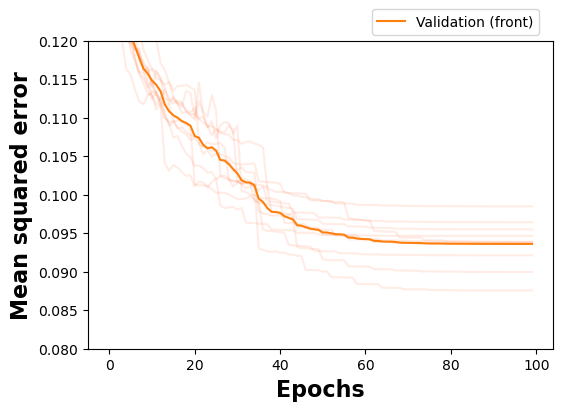

In [25]:
fig, ax = plt.subplots(1,1, figsize = (6,4))
for i in range(10):
    #ax.plot(history_seeds[i][requested_param], color = 'C9', alpha = 0.1)
    ax.plot(history_seeds[i][rp_val], color = 'orangered', alpha = 0.1)
std_f = 1

df = df_ALL
#ax.fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'orangered')
ax.plot(df[rp_val_mean], label = 'Validation (front)', color = 'C1')
#ax.fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C1')

fontsize = 16
ax.set_xlabel('Epochs', fontsize = fontsize, weight = 'bold')
ax.set_ylabel(rp_label, fontsize = fontsize, weight = 'bold')
ax.legend(fontsize = fontsize-6, markerscale = 2, loc = (0.61, 1.02))
if requested_param == 'mae':
    ax.set_ylim(None, 0.15)
elif requested_param == 'loss':
    ax.set_ylim(0.06,0.09)
elif requested_param == 'mse':
    ax.set_ylim(0.08,0.12)

In [5]:
seed_nb_array = np.arange(1,11,1)
history_seeds = np.ndarray(len(seed_nb_array), dtype = np.ndarray)
history_seeds2 = np.ndarray(len(seed_nb_array), dtype = np.ndarray)
for i in seed_nb_array:
    history_seeds[i-1] = load_history('slope_lat_lon', 'no_middle_5', seed_nb = i, verbose = 0)
    history_seeds2[i-1] = load_history('slope_front', 'no_middle_5', seed_nb = i, verbose = 0)

In [7]:
df_lat_lon = calculate_mean_std(history_seeds)
df_front = calculate_mean_std(history_seeds2)


In [8]:
requested_param = 'mse' # 'loss', 'mae', 'mse'
if requested_param == 'mae':
    rp_label = 'Mean absolute error'
elif requested_param == 'loss':
    rp_label = 'Loss'
elif requested_param == 'mse':
    rp_label = 'Mean squared error'

In [9]:
rp_val = 'val_' + requested_param
rp_mean = requested_param + '_mean'
rp_std = requested_param + '_std'
rp_val_mean = 'val_' + requested_param + '_mean'
rp_val_std = 'val_' + requested_param + '_std'

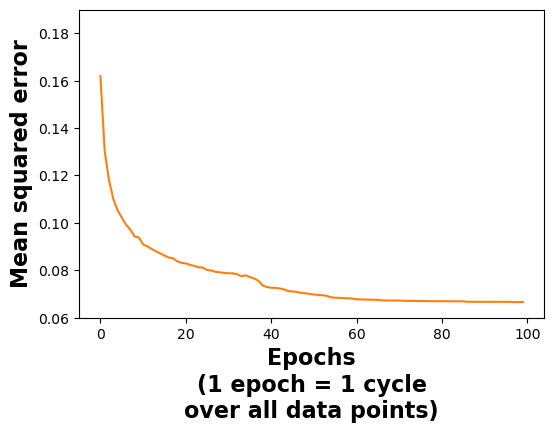

In [11]:
fig, ax = plt.subplots(1,1, figsize = (6,4))
#for i in range(10):
#for i in range(1):
    #ax.plot(history_seeds[i][requested_param], color = 'C9', alpha = 0.1)
 #   ax.plot(history_seeds[i][rp_val], color = 'C0', alpha = 0.1)
    #ax.plot(history_seeds2[i][requested_param], color = 'C1', alpha = 0.1)
    #ax.plot(history_seeds2[i][rp_val], color = 'orangered', alpha = 0.1)
std_f = 1
#df = df_lat_lon
#ax.plot(df[rp_mean], label = 'Training (lat_lon)', color = 'C0')
#ax.fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'C0')
#ax.plot(df[rp_val_mean], color = 'C9')
#ax.fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C9')

df = df_front
#ax.plot(df[rp_mean], label = 'Training (front)', color = 'orangered')
#ax.fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'orangered')
ax.plot(df[rp_val_mean], label = 'Validation (front)', color = 'C1')
#ax.fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C1')

fontsize = 16
ax.set_xlabel('Epochs\n(1 epoch = 1 cycle\nover all data points)', fontsize = fontsize, weight = 'bold')
ax.set_ylabel(rp_label, fontsize = fontsize, weight = 'bold')
#ax.legend(fontsize = fontsize-6, markerscale = 2, loc = (0.61, 1.02))
if requested_param == 'mae':
    ax.set_ylim(None, 0.15)
elif requested_param == 'loss':
    ax.set_ylim(0.06,0.09)
elif requested_param == 'mse':
    ax.set_ylim(0.06,0.19)

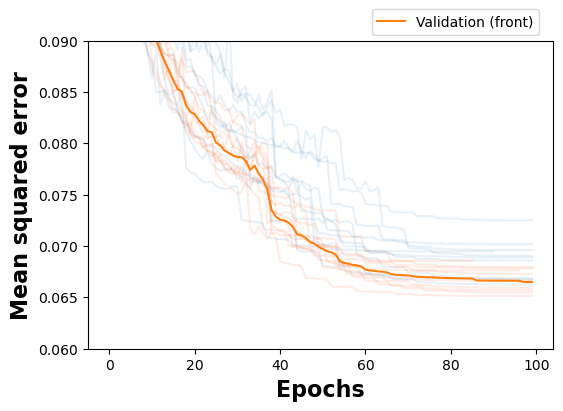

In [12]:
fig, ax = plt.subplots(1,1, figsize = (6,4))
for i in range(10):
    #ax.plot(history_seeds[i][requested_param], color = 'C9', alpha = 0.1)
    ax.plot(history_seeds[i][rp_val], color = 'C0', alpha = 0.1)
    #ax.plot(history_seeds2[i][requested_param], color = 'C1', alpha = 0.1)
    ax.plot(history_seeds2[i][rp_val], color = 'orangered', alpha = 0.1)
std_f = 1
#df = df_lat_lon
#ax.plot(df[rp_mean], label = 'Training (lat_lon)', color = 'C0')
#ax.fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'C0')
#ax.plot(df[rp_val_mean], label = 'Validation (lat_lon)', color = 'C9')
#ax.fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C9')

df = df_front
#ax.plot(df[rp_mean], label = 'Training (front)', color = 'orangered')
#ax.fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'orangered')
ax.plot(df[rp_val_mean], label = 'Validation (front)', color = 'C1')
#ax.fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C1')

fontsize = 16
ax.set_xlabel('Epochs', fontsize = fontsize, weight = 'bold')
ax.set_ylabel(rp_label, fontsize = fontsize, weight = 'bold')
ax.legend(fontsize = fontsize-6, markerscale = 2, loc = (0.61, 1.02))
if requested_param == 'mae':
    ax.set_ylim(None, 0.15)
elif requested_param == 'loss':
    ax.set_ylim(0.06,0.09)
elif requested_param == 'mse':
    ax.set_ylim(0.06,0.09)

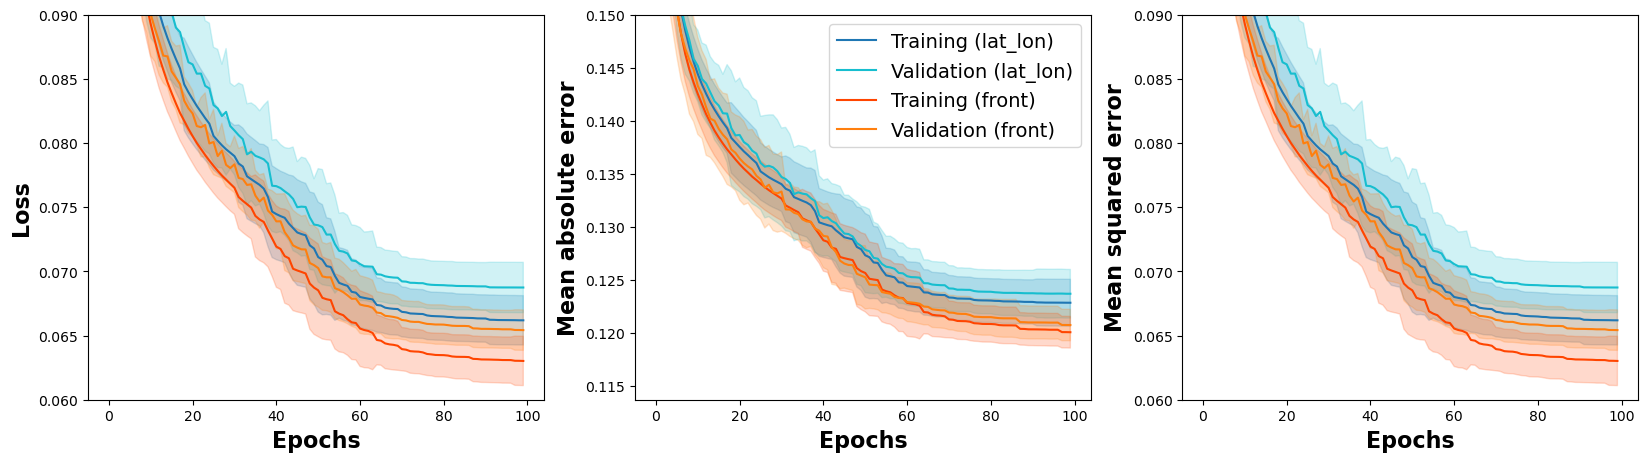

In [11]:
fig, ax = plt.subplots(1,3, figsize = (20,5))
requested_parameters = ('loss', 'mae', 'mse')
labels = ('Loss', 'Mean absolute error', 'Mean squared error')
ylims = ((0.06,0.09), (None, 0.15), (0.06,0.09))
std_f = 1
fontsize = 16
for i in range(len(requested_parameters)):
    requested_param = requested_parameters[i]
    rp_val = 'val_' + requested_param
    rp_mean = requested_param + '_mean'
    rp_std = requested_param + '_std'
    rp_val_mean = 'val_' + requested_param + '_mean'
    rp_val_std = 'val_' + requested_param + '_std'
    df = df_lat_lon
    ax[i].plot(df[rp_mean], label = 'Training (lat_lon)', color = 'C0')
    ax[i].fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'C0')
    ax[i].plot(df[rp_val_mean], label = 'Validation (lat_lon)', color = 'C9')
    ax[i].fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C9')

    df = df_front
    ax[i].plot(df[rp_mean], label = 'Training (front)', color = 'orangered')
    ax[i].fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'orangered')
    ax[i].plot(df[rp_val_mean], label = 'Validation (front)', color = 'C1')
    ax[i].fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C1')


    #ax[i].plot(df[rp_mean], label = 'Training')
    #ax[i].fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2)
    #ax[i].plot(df[rp_val_mean], label = 'Validation')
    #ax[i].fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2)
    fontsize = 16
    ax[i].set_xlabel('Epochs', fontsize = fontsize, weight = 'bold')
    ax[i].set_ylabel(labels[i], fontsize = fontsize, weight = 'bold')
    ax[i].set_ylim(ylims[i])
ax[1].legend(fontsize = fontsize-2, markerscale = 2)
    